# Regularized MAP inversion of a Lyα forest

This notebook extends the direct fluctuating Gunn–Peterson approximation (FGPA) inversion to a mock observed spectrum with finite resolution and noise. We compare two reconstructions:

- **Direct pixelwise FGPA:** invert the local density–temperature opacity in each observed pixel.
- **Regularized MAP inversion:** infer the complete density field by fitting a forward model containing the nonlinear FGPA mapping, instrumental line-spread function, and noise.

The mock data use the actual CAMELS temperature, but neither inverse receives that hidden field. Direct FGPA and MAP instead share an assumed $T_0$–$\gamma$ relation. Their remaining difference is how they treat the observation process and the ill-posed inverse problem.

## 1. Imports and configuration

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from scipy import ndimage
from scipy.optimize import brentq, least_squares

from astropy import units as u
from astropy.cosmology import Planck18 as cosmo

data_directory = Path("Sims/CMD_z=2_grid128")
output_directory = Path("figures")
output_directory.mkdir(exist_ok=True)

seed = 0
y_index = 64
z_index = 64
box_size = 25.0       # comoving Mpc/h
box_redshift = 2.0

# === User-adjustable mock-observation settings ===
signal_to_noise = 5.0         # S/N per native flux pixel
instrument_fwhm_kms = 120.0  # Gaussian instrumental FWHM [km/s]
noise_seed = 2026

# === Assumed thermal relation available to the inversion (not the simulator truth) ===
inversion_T0_K = 10_000.0
inversion_gamma = 1.5

## 2. The latent fields and FGPA parameters

As before, we use overdensity factors

$$\Delta_b=\rho_b/\bar\rho_b, \qquad \Delta_{\rm dm}=\rho_{\rm dm}/\bar\rho_{\rm dm}.$$

The means are calculated from the full three-dimensional CAMELS box rather than from the selected sightline. The mock forest uses the actual co-spatial CAMELS temperature field. Its local opacity is

$$\tau=A\Delta_b^2\left(\frac{T_{\rm CAMELS}}{10^4\,\mathrm K}\right)^{-0.7}, \qquad F_{\rm int}=e^{-\tau}.$$

The $10^4$ K reference only makes the temperature factor dimensionless; it is not an imposed equation of state. The amplitude $A$ is pre-calibrated on the other 26 simulation boxes to the illustrative observable mean transmission $\langle F_{\rm int}\rangle=0.82$ and then fixed for test box 0.

In [2]:
gas_boxes = np.load(
    data_directory / "Grids_Mgas_IllustrisTNG_CV_128_z=2.0.npy",
    mmap_mode="r",
)
dm_boxes = np.load(
    data_directory / "Grids_Mcdm_IllustrisTNG_CV_128_z=2.0.npy",
    mmap_mode="r",
)
temperature_boxes = np.load(
    data_directory / "Grids_T_IllustrisTNG_CV_128_z=2.0.npy",
    mmap_mode="r",
)

number_of_cells = gas_boxes.shape[1]
cell_size = box_size / number_of_cells
x = (np.arange(number_of_cells) + 0.5) * cell_size

gas_box_mean = gas_boxes[seed].mean(dtype=np.float64)
dm_box_mean = dm_boxes[seed].mean(dtype=np.float64)
Delta_b_true = (
    gas_boxes[seed, :, y_index, z_index].astype(np.float64) / gas_box_mean
)
Delta_dm_true = (
    dm_boxes[seed, :, y_index, z_index].astype(np.float64) / dm_box_mean
)
temperature_camels = temperature_boxes[seed, :, y_index, z_index].astype(np.float64)

temperature_reference = 10_000.0  # K; normalization only
temperature_factor = (temperature_camels / temperature_reference) ** (-0.7)
inversion_beta = 2.0 - 0.7 * (inversion_gamma - 1.0)
inversion_temperature_normalization = (inversion_T0_K/temperature_reference) ** (-0.7)
target_mean_flux = 0.82
opacity_shape_true = Delta_b_true**2 * temperature_factor
calibration_simulations = [sim for sim in range(gas_boxes.shape[0]) if sim != seed]
calibration_opacity_shape = np.concatenate([
    (gas_boxes[sim, :, y_index, z_index].astype(np.float64) / gas_boxes[sim].mean(dtype=np.float64))**2
    * (temperature_boxes[sim, :, y_index, z_index].astype(np.float64)/temperature_reference)**(-0.7)
    for sim in calibration_simulations
])

def mean_flux_residual(A):
    return np.mean(np.exp(-A * calibration_opacity_shape)) - target_mean_flux

A_fgpa = brentq(mean_flux_residual, 1.0e-6, 100.0)
optical_depth_true = A_fgpa * opacity_shape_true
flux_intrinsic_true = np.exp(-optical_depth_true)

print(f"Cell width = {cell_size:.3f} comoving Mpc/h")
print(f"Actual CAMELS temperature range = [{temperature_camels.min():.0f}, {temperature_camels.max():.0f}] K")
print(f"Inverse assumes T0={inversion_T0_K:.0f} K, gamma={inversion_gamma:.2f}, beta={inversion_beta:.3f}")
print(f"A = {A_fgpa:.5f}, calibrated on {len(calibration_simulations)} non-test boxes")
print(f"Held-out intrinsic mean flux = {flux_intrinsic_true.mean():.3f}")

Cell width = 0.195 comoving Mpc/h
Actual CAMELS temperature range = [4883, 137569] K
Inverse assumes T0=10000 K, gamma=1.50, beta=1.650
A = 0.44503, calibrated on 26 non-test boxes
Held-out intrinsic mean flux = 0.806


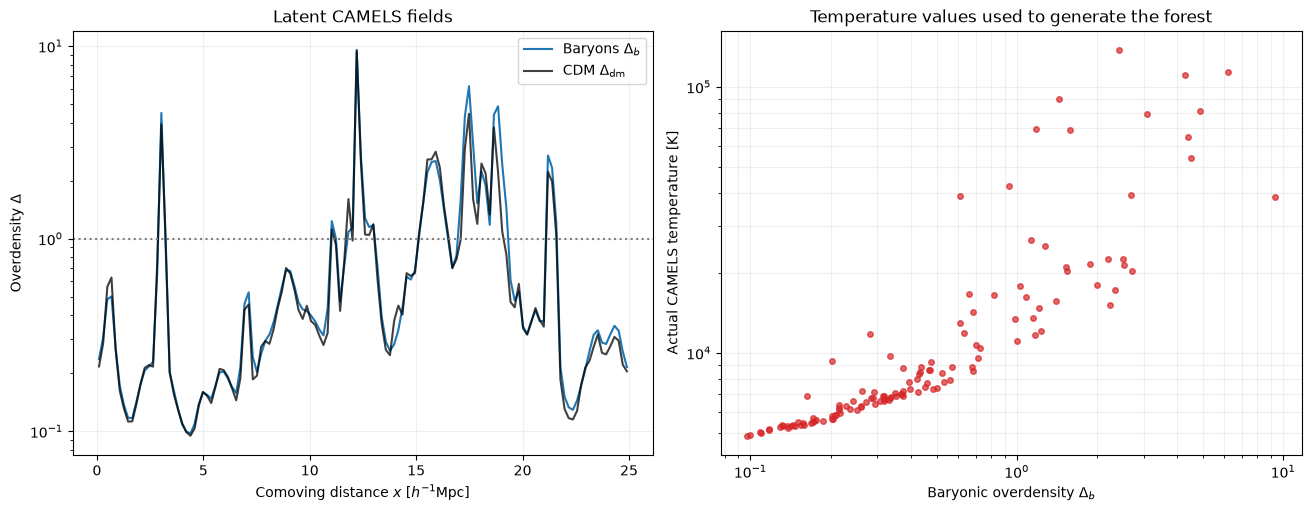

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5), constrained_layout=True)

axes[0].semilogy(x, Delta_b_true, color="tab:blue", label=r"Baryons $\Delta_b$")
axes[0].semilogy(x, Delta_dm_true, color="black", alpha=0.75, label=r"CDM $\Delta_{\rm dm}$")
axes[0].axhline(1.0, color="0.5", ls=":")
axes[0].set_xlabel(r"Comoving distance $x\ [h^{-1}{\rm Mpc}]$")
axes[0].set_ylabel(r"Overdensity $\Delta$")
axes[0].set_title("Latent CAMELS fields")
axes[0].legend()
axes[0].grid(alpha=0.2)

axes[1].loglog(Delta_b_true, temperature_camels, "o", ms=4, color="tab:red", alpha=.7)
axes[1].set_xlabel(r"Baryonic overdensity $\Delta_b$")
axes[1].set_ylabel("Actual CAMELS temperature [K]")
axes[1].set_title("Temperature values used to generate the forest")
axes[1].grid(alpha=0.2, which="both")

fig.savefig(output_directory / "MAP_latent_fields_and_temperature.png", dpi=150, bbox_inches="tight")
plt.show()

## 3. Construct a mock observation

The instrument acts on flux rather than directly on density or optical depth. With a Gaussian line-spread matrix $K$, the observed data are

$$\mathbf d=K\mathbf F_{\rm int}+\mathbf n,$$

where $n_i\sim\mathcal N(0,\sigma_F^2)$. The defaults are a Gaussian instrumental $\mathrm{FWHM}_v=50\ {\rm km\,s^{-1}}$ and $\mathrm{S/N}=20$ per native pixel. Both are exposed in the first configuration cell and can be changed before running the notebook.

The Gaussian width used by the convolution is

$$\sigma_v=\frac{\mathrm{FWHM}_v}{2\sqrt{2\ln2}}, \qquad \sigma_{\rm pixel}=\frac{\sigma_v}{\Delta v_{\rm pixel}}.$$

The matrix representation is useful beyond this notebook: $K$ could instead describe a point-spread function, a projection kernel, incomplete sampling, or another tracer response.

In [4]:
H_z = cosmo.H(box_redshift).to_value(u.km / u.s / u.Mpc)
velocity_pixel_width = H_z * (cell_size / cosmo.h) / (1.0 + box_redshift)

instrument_sigma_pixels = (
    instrument_fwhm_kms
    / (2.0 * np.sqrt(2.0 * np.log(2.0)))
    / velocity_pixel_width
)

# Construct the exact linear operator used in both simulation and inversion.
identity = np.eye(number_of_cells)
instrument_matrix = ndimage.gaussian_filter1d(
    identity,
    instrument_sigma_pixels,
    axis=0,
    mode="reflect",
)
flux_convolved_true = instrument_matrix @ flux_intrinsic_true

noise_sigma = 1.0 / signal_to_noise
noise_rng = np.random.default_rng(noise_seed)
flux_observed = flux_convolved_true + noise_rng.normal(
    0.0, noise_sigma, number_of_cells
)

print(f"Native velocity width = {velocity_pixel_width:.2f} km/s per pixel")
print(f"Instrument FWHM = {instrument_fwhm_kms:.2f} km/s")
print(f"FWHM sampling = {instrument_fwhm_kms / velocity_pixel_width:.2f} pixels")
print(f"Signal-to-noise per native pixel = {signal_to_noise:.1f}")
print(f"Noise sigma_F = {noise_sigma:.4f}")
print(f"Instrument preserves a constant continuum: {np.max(np.abs(instrument_matrix @ np.ones(number_of_cells) - 1.0)):.2e}")

Native velocity width = 19.63 km/s per pixel
Instrument FWHM = 120.00 km/s
FWHM sampling = 6.11 pixels
Signal-to-noise per native pixel = 5.0
Noise sigma_F = 0.2000
Instrument preserves a constant continuum: 0.00e+00


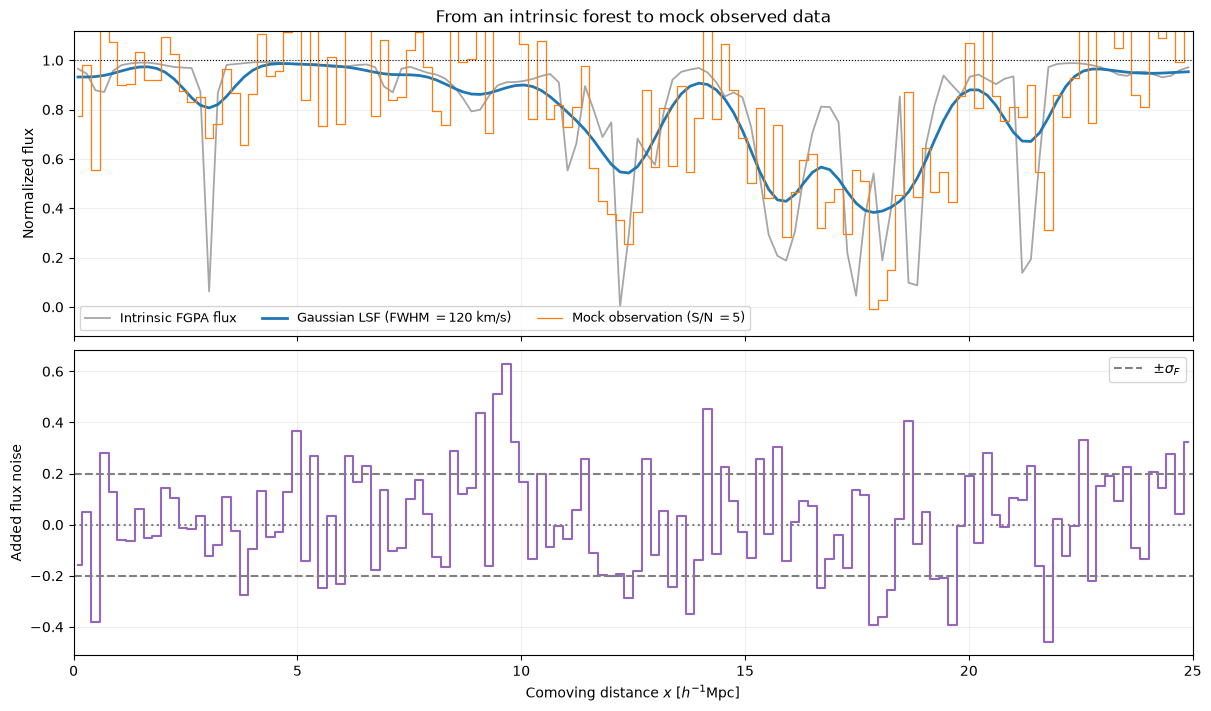

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True, constrained_layout=True)

axes[0].plot(x, flux_intrinsic_true, color="0.65", lw=1.3, label="Intrinsic FGPA flux")
axes[0].plot(x, flux_convolved_true, color="tab:blue", lw=2.0, label=rf"Gaussian LSF (FWHM $={instrument_fwhm_kms:.0f}$ km/s)")
axes[0].step(x, flux_observed, where="mid", color="tab:orange", lw=0.9, label=rf"Mock observation (S/N $={signal_to_noise:.0f}$)")
axes[0].axhline(1.0, color="black", ls=":", lw=0.8)
axes[0].set_ylabel("Normalized flux")
axes[0].set_ylim(-0.12, 1.12)
axes[0].set_title("From an intrinsic forest to mock observed data")
axes[0].legend(ncol=3, fontsize=9)

axes[1].step(x, flux_observed - flux_convolved_true, where="mid", color="tab:purple")
axes[1].axhline(0.0, color="0.5", ls=":")
axes[1].axhline(noise_sigma, color="0.5", ls="--", label=r"$\pm\sigma_F$")
axes[1].axhline(-noise_sigma, color="0.5", ls="--")
axes[1].set_ylabel("Added flux noise")
axes[1].set_xlabel(r"Comoving distance $x\ [h^{-1}{\rm Mpc}]$")
axes[1].legend()

for ax in axes:
    ax.grid(alpha=0.2)
    ax.set_xlim(0.0, box_size)

fig.savefig(output_directory / "MAP_mock_observation.png", dpi=150, bbox_inches="tight")
plt.show()

## 4. Baseline: direct pixelwise FGPA inversion

The direct inverse is

Because an observation does not provide $T(x)$, the inverse assumes $T=T_0\Delta_b^{\gamma-1}$ and $\beta=2-0.7(\gamma-1)$:

$$\Delta_{b,\rm direct}=\left[\frac{-\ln F_{\rm obs}}{A(T_0/10^4\,\mathrm K)^{-0.7}}\right]^{1/\beta}.$$

The hidden CAMELS temperature used by the simulator is not supplied here. The direct inverse also ignores the LSF, although each observed pixel contains flux from its neighbours. Noise can produce $F_{\rm obs}\leq0$ or $F_{\rm obs}>1$, for which the expression is invalid. For this baseline only, we clip to $\sigma_F\leq F<1$.

In [6]:
direct_flux_floor = noise_sigma
direct_flux_ceiling = 1.0 - 1.0e-8
flux_for_direct_inverse = np.clip(
    flux_observed, direct_flux_floor, direct_flux_ceiling
)
Delta_b_direct = (
    -np.log(flux_for_direct_inverse) / (A_fgpa * inversion_temperature_normalization)
) ** (1.0/inversion_beta)

number_below_floor = np.count_nonzero(flux_observed < direct_flux_floor)
number_above_continuum = np.count_nonzero(flux_observed >= 1.0)
print(f"Pixels placed at the low-flux limit: {number_below_floor}")
print(f"Pixels with F >= 1 clipped below the continuum: {number_above_continuum}")

Pixels placed at the low-flux limit: 3
Pixels with F >= 1 clipped below the continuum: 37


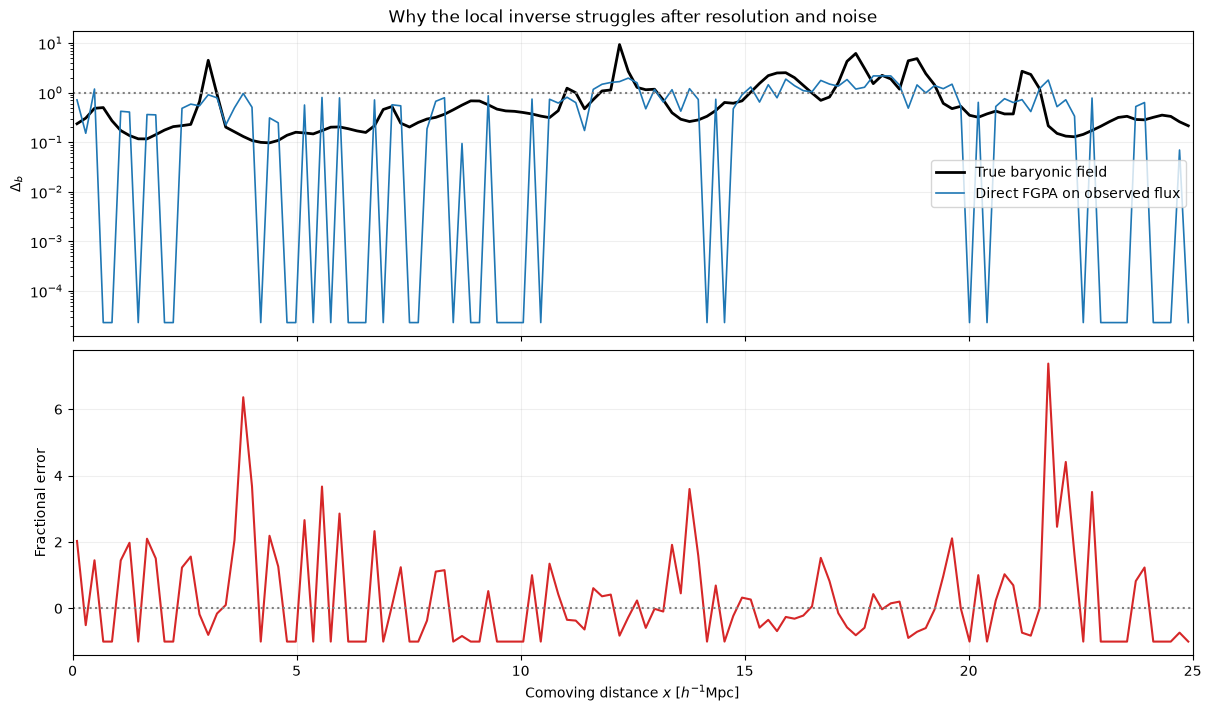

In [7]:
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True, constrained_layout=True)

axes[0].semilogy(x, Delta_b_true, color="black", lw=2.0, label="True baryonic field")
axes[0].semilogy(x, Delta_b_direct, color="tab:blue", lw=1.2, label="Direct FGPA on observed flux")
axes[0].axhline(1.0, color="0.5", ls=":")
axes[0].set_ylabel(r"$\Delta_b$")
axes[0].set_title("Why the local inverse struggles after resolution and noise")
axes[0].legend()

direct_fractional_error = (Delta_b_direct - Delta_b_true) / Delta_b_true
axes[1].plot(x, direct_fractional_error, color="tab:red")
axes[1].axhline(0.0, color="0.5", ls=":")
axes[1].set_ylabel("Fractional error")
axes[1].set_xlabel(r"Comoving distance $x\ [h^{-1}{\rm Mpc}]$")

for ax in axes:
    ax.grid(alpha=0.2)
    ax.set_xlim(0.0, box_size)

fig.savefig(output_directory / "MAP_direct_FGPA_baseline.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. Regularized MAP formulation

Use log-density as the latent field,

$$s_i=\ln\Delta_{b,i},$$

so positivity is automatic. The forward prediction is

The MAP forward model may use only the assumed thermal relation, not the hidden simulator temperature:

$$\mathbf m(\mathbf s)=K\exp\left[-A(T_0/10^4\,\mathrm K)^{-0.7}\exp(\beta\mathbf s)\right].$$

For independent Gaussian flux noise, a regularized maximum-a-posteriori estimate minimizes

$$\Phi(\mathbf s)=\frac{1}{2}\left\|\frac{\mathbf m(\mathbf s)-\mathbf d}{\sigma_F}\right\|^2+\frac{\lambda}{2}\lVert L\mathbf s\rVert^2.$$

$L$ is a second-difference matrix, so $L\mathbf s$ measures discrete curvature. The penalty suppresses rapid oscillations that can fit noise after deconvolution. Small $\lambda$ permits noisy structure; large $\lambda$ oversmooths the field. This is a Gaussian prior on the curvature of log-density.

The analytic intrinsic-flux derivative used by the iterative solver is

$$\frac{\partial F_{\rm int}}{\partial s}=-\beta\tau e^{-\tau}.$$

In [8]:
# L has rows [1, -2, 1], acting on adjacent log-density pixels.
curvature_matrix = np.zeros((number_of_cells - 2, number_of_cells))
for row in range(number_of_cells - 2):
    curvature_matrix[row, row : row + 3] = [1.0, -2.0, 1.0]

def forward_components(log_density):
    """Return intrinsic flux, observed-model flux, and its Jacobian."""
    optical_depth = A_fgpa * inversion_temperature_normalization * np.exp(inversion_beta * log_density)
    intrinsic_flux = np.exp(-optical_depth)
    derivative_intrinsic = -inversion_beta * optical_depth * intrinsic_flux
    model_flux = instrument_matrix @ intrinsic_flux
    jacobian_model = instrument_matrix * derivative_intrinsic[None, :]
    return intrinsic_flux, model_flux, jacobian_model

def map_residual(log_density, regularization_strength):
    _, model_flux, _ = forward_components(log_density)
    data_residual = (model_flux - flux_observed) / noise_sigma
    prior_residual = (
        np.sqrt(regularization_strength) * curvature_matrix @ log_density
    )
    return np.concatenate([data_residual, prior_residual])

def map_jacobian(log_density, regularization_strength):
    _, _, jacobian_model = forward_components(log_density)
    return np.vstack([
        jacobian_model / noise_sigma,
        np.sqrt(regularization_strength) * curvature_matrix,
    ])

# A smoothed direct inversion provides a finite starting point, not a prior truth.
initial_Delta = np.clip(
    ndimage.gaussian_filter1d(Delta_b_direct, 1.0, mode="reflect"),
    0.03,
    20.0,
)
initial_log_density = np.log(initial_Delta)
lower_bound = np.full(number_of_cells, np.log(0.03))
upper_bound = np.full(number_of_cells, np.log(20.0))

## 6. Select the regularization strength without using density truth

We solve for a small grid of $\lambda$ values. For each solution we record

$$\chi^2_{\rm data}/N=\frac{1}{N}\sum_i\left(\frac{m_i-d_i}{\sigma_F}\right)^2$$

and the RMS curvature of $s$. The **discrepancy principle** selects the candidate with $\chi^2_{\rm data}/N$ closest to one: residuals should be comparable to the known noise, rather than driven artificially toward zero. CAMELS density truth is not involved in this selection.

In [9]:
lambda_grid = np.array([1_000.0, 100.0, 10.0, 1.0, 0.1, 0.01])
map_solutions = {}
data_chi2_per_pixel = {}
rms_curvature = {}

starting_point = initial_log_density.copy()
for regularization_strength in lambda_grid:
    result = least_squares(
        map_residual,
        starting_point,
        jac=map_jacobian,
        args=(regularization_strength,),
        bounds=(lower_bound, upper_bound),
        max_nfev=100,
        ftol=1.0e-8,
        xtol=1.0e-8,
        gtol=1.0e-8,
    )
    log_density_solution = result.x
    _, model_flux, _ = forward_components(log_density_solution)
    map_solutions[regularization_strength] = log_density_solution
    data_chi2_per_pixel[regularization_strength] = np.mean(
        ((model_flux - flux_observed) / noise_sigma) ** 2
    )
    rms_curvature[regularization_strength] = np.sqrt(
        np.mean((curvature_matrix @ log_density_solution) ** 2)
    )
    starting_point = log_density_solution

selected_lambda = min(
    lambda_grid,
    key=lambda value: abs(data_chi2_per_pixel[value] - 1.0),
)
selected_log_density = map_solutions[selected_lambda]
Delta_b_map = np.exp(selected_log_density)
flux_intrinsic_map, flux_model_map, _ = forward_components(selected_log_density)

print("lambda    chi2_data/N    RMS curvature")
for value in lambda_grid:
    marker = " <-- selected" if value == selected_lambda else ""
    print(
        f"{value:7.2g}    {data_chi2_per_pixel[value]:11.3f}"
        f"    {rms_curvature[value]:13.4f}{marker}"
    )

lambda    chi2_data/N    RMS curvature
  1e+03          1.074           0.0088
  1e+02          0.943           0.0235 <-- selected
     10          0.872           0.0546
      1          0.832           0.1334
    0.1          0.809           0.3167
   0.01          0.799           0.6455


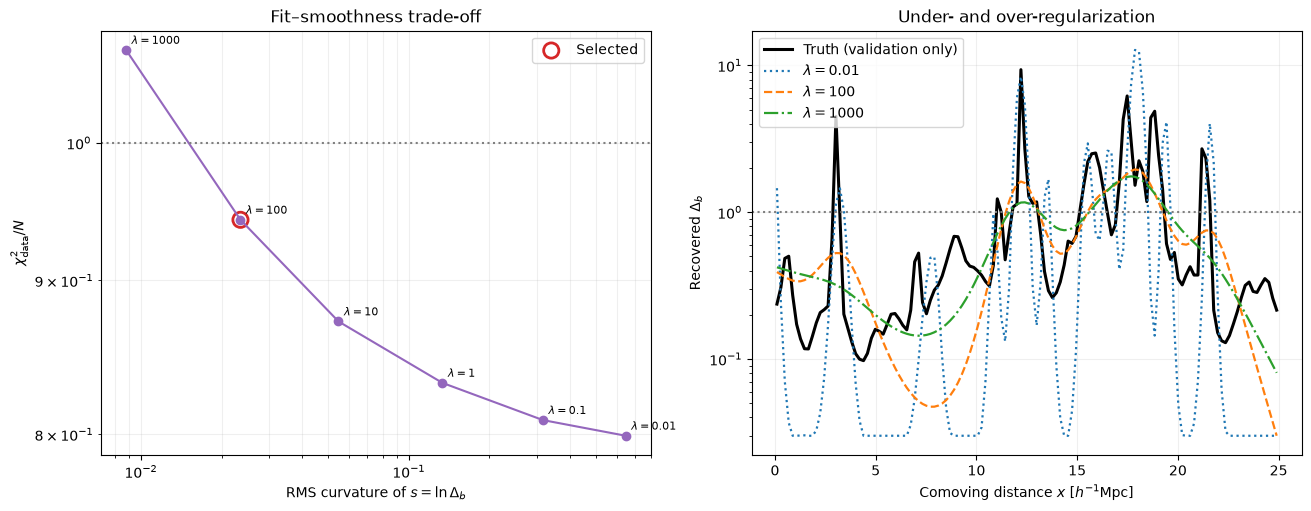

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5), constrained_layout=True)

lambda_for_plot = lambda_grid[::-1]
chi2_for_plot = np.array([data_chi2_per_pixel[value] for value in lambda_for_plot])
roughness_for_plot = np.array([rms_curvature[value] for value in lambda_for_plot])

axes[0].loglog(roughness_for_plot, chi2_for_plot, "o-", color="tab:purple")
for value, roughness, chi2 in zip(lambda_for_plot, roughness_for_plot, chi2_for_plot):
    axes[0].annotate(rf"$\lambda={value:g}$", (roughness, chi2), xytext=(4, 4), textcoords="offset points", fontsize=8)
axes[0].axhline(1.0, color="0.5", ls=":")
axes[0].scatter(
    [rms_curvature[selected_lambda]],
    [data_chi2_per_pixel[selected_lambda]],
    s=120,
    facecolor="none",
    edgecolor="tab:red",
    lw=2.0,
    label="Selected",
)
axes[0].set_xlabel(r"RMS curvature of $s=\ln\Delta_b$")
axes[0].set_ylabel(r"$\chi^2_{\rm data}/N$")
axes[0].set_title("Fit–smoothness trade-off")
axes[0].legend()
axes[0].grid(alpha=0.2, which="both")

axes[1].semilogy(x, Delta_b_true, color="black", lw=2.2, label="Truth (validation only)")
for value, style, color in [
    (0.01, ":", "tab:blue"),
    (selected_lambda, "--", "tab:orange"),
    (1_000.0, "-.", "tab:green"),
]:
    axes[1].semilogy(
        x,
        np.exp(map_solutions[value]),
        style,
        color=color,
        lw=1.6,
        label=rf"$\lambda={value:g}$",
    )
axes[1].axhline(1.0, color="0.5", ls=":")
axes[1].set_xlabel(r"Comoving distance $x\ [h^{-1}{\rm Mpc}]$")
axes[1].set_ylabel(r"Recovered $\Delta_b$")
axes[1].set_title("Under- and over-regularization")
axes[1].legend()
axes[1].grid(alpha=0.2)

fig.savefig(output_directory / "MAP_regularization_selection.png", dpi=150, bbox_inches="tight")
plt.show()

A weak penalty allows deconvolution to amplify noise. A very strong penalty forces an unrealistically smooth field and leaves structure in the data residuals. The selected solution balances these behaviours using the stated noise level.

## 7. Check the selected solution in data and density space

A reconstruction should be inspected in observation space as well as against simulation truth. If the model is adequate, normalized residuals $(d-m)/\sigma_F$ should fluctuate around zero with order-unity scatter and should not contain coherent absorption features.

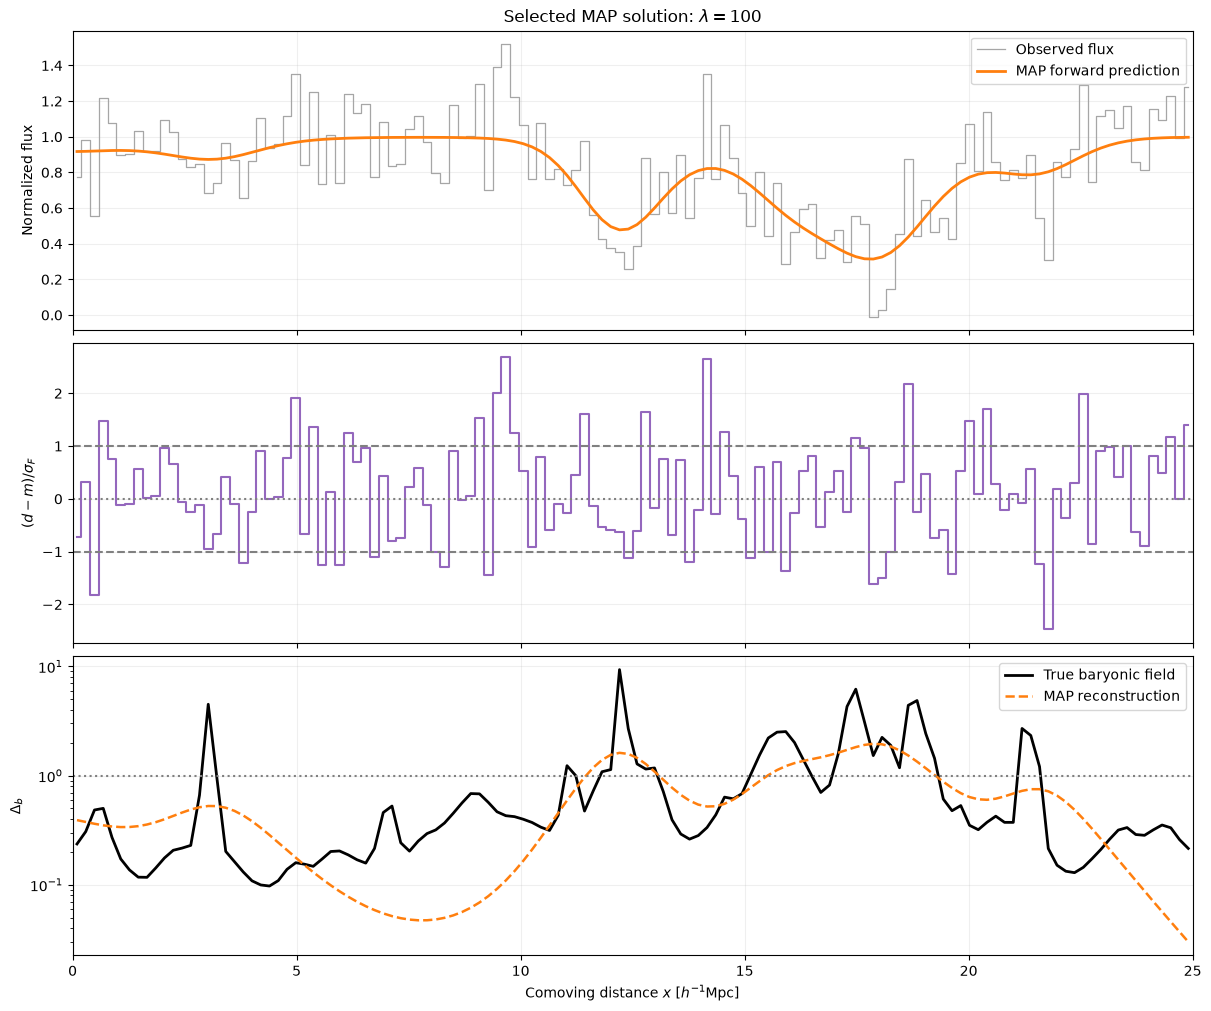

In [11]:
normalized_map_residual = (flux_observed - flux_model_map) / noise_sigma

fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True, constrained_layout=True)

axes[0].step(x, flux_observed, where="mid", color="0.65", lw=0.9, label="Observed flux")
axes[0].plot(x, flux_model_map, color="tab:orange", lw=2.0, label="MAP forward prediction")
axes[0].set_ylabel("Normalized flux")
axes[0].set_title(rf"Selected MAP solution: $\lambda={selected_lambda:g}$")
axes[0].legend()

axes[1].step(x, normalized_map_residual, where="mid", color="tab:purple")
axes[1].axhline(0.0, color="0.5", ls=":")
axes[1].axhline(1.0, color="0.5", ls="--")
axes[1].axhline(-1.0, color="0.5", ls="--")
axes[1].set_ylabel(r"$(d-m)/\sigma_F$")

axes[2].semilogy(x, Delta_b_true, color="black", lw=2.0, label="True baryonic field")
axes[2].semilogy(x, Delta_b_map, "--", color="tab:orange", lw=1.8, label="MAP reconstruction")
axes[2].axhline(1.0, color="0.5", ls=":")
axes[2].set_ylabel(r"$\Delta_b$")
axes[2].set_xlabel(r"Comoving distance $x\ [h^{-1}{\rm Mpc}]$")
axes[2].legend()

for ax in axes:
    ax.grid(alpha=0.2)
    ax.set_xlim(0.0, box_size)

fig.savefig(output_directory / "MAP_selected_solution.png", dpi=150, bbox_inches="tight")
plt.show()

## 8. Final comparison with direct FGPA inversion

For both reconstructions, construct the same model-dependent dark-matter proxy used previously:

$$\Delta_{\rm dm,pred}\simeq\Delta_{b,\rm rec}.$$

This step assumes baryons trace dark matter; Lyα does not directly observe DM. We compare fields, reconstruction errors, correlations, and the one-dimensional DM power spectrum.

In [12]:
Delta_dm_direct = Delta_b_direct.copy()
Delta_dm_map = Delta_b_map.copy()

def reconstruction_metrics(truth, prediction):
    return {
        "RMSE": np.sqrt(np.mean((prediction - truth) ** 2)),
        "MAE": np.mean(np.abs(prediction - truth)),
        "Bias": np.mean(prediction - truth),
        "Correlation": np.corrcoef(truth, prediction)[0, 1],
    }

metrics = {
    "Baryon: direct FGPA": reconstruction_metrics(Delta_b_true, Delta_b_direct),
    "Baryon: MAP": reconstruction_metrics(Delta_b_true, Delta_b_map),
    "DM proxy: direct FGPA": reconstruction_metrics(Delta_dm_true, Delta_dm_direct),
    "DM proxy: MAP": reconstruction_metrics(Delta_dm_true, Delta_dm_map),
}

print(f"{'Reconstruction':27s} {'RMSE':>8s} {'MAE':>8s} {'Bias':>8s} {'r':>8s}")
for name, values in metrics.items():
    print(
        f"{name:27s} {values['RMSE']:8.3f} {values['MAE']:8.3f}"
        f" {values['Bias']:8.3f} {values['Correlation']:8.3f}"
    )

def one_dimensional_power(Delta, spacing):
    density_contrast = Delta - 1.0
    fourier_amplitude = spacing * np.fft.rfft(density_contrast)
    k = 2.0 * np.pi * np.fft.rfftfreq(Delta.size, d=spacing)
    power = np.abs(fourier_amplitude) ** 2 / (Delta.size * spacing)
    return k[1:], power[1:]

k_dm, power_dm_true = one_dimensional_power(Delta_dm_true, cell_size)
_, power_dm_direct = one_dimensional_power(Delta_dm_direct, cell_size)
_, power_dm_map = one_dimensional_power(Delta_dm_map, cell_size)

Reconstruction                  RMSE      MAE     Bias        r
Baryon: direct FGPA            1.146    0.605   -0.237    0.500
Baryon: MAP                    1.076    0.510   -0.269    0.635
DM proxy: direct FGPA          0.999    0.541   -0.147    0.500
DM proxy: MAP                  0.938    0.453   -0.180    0.609


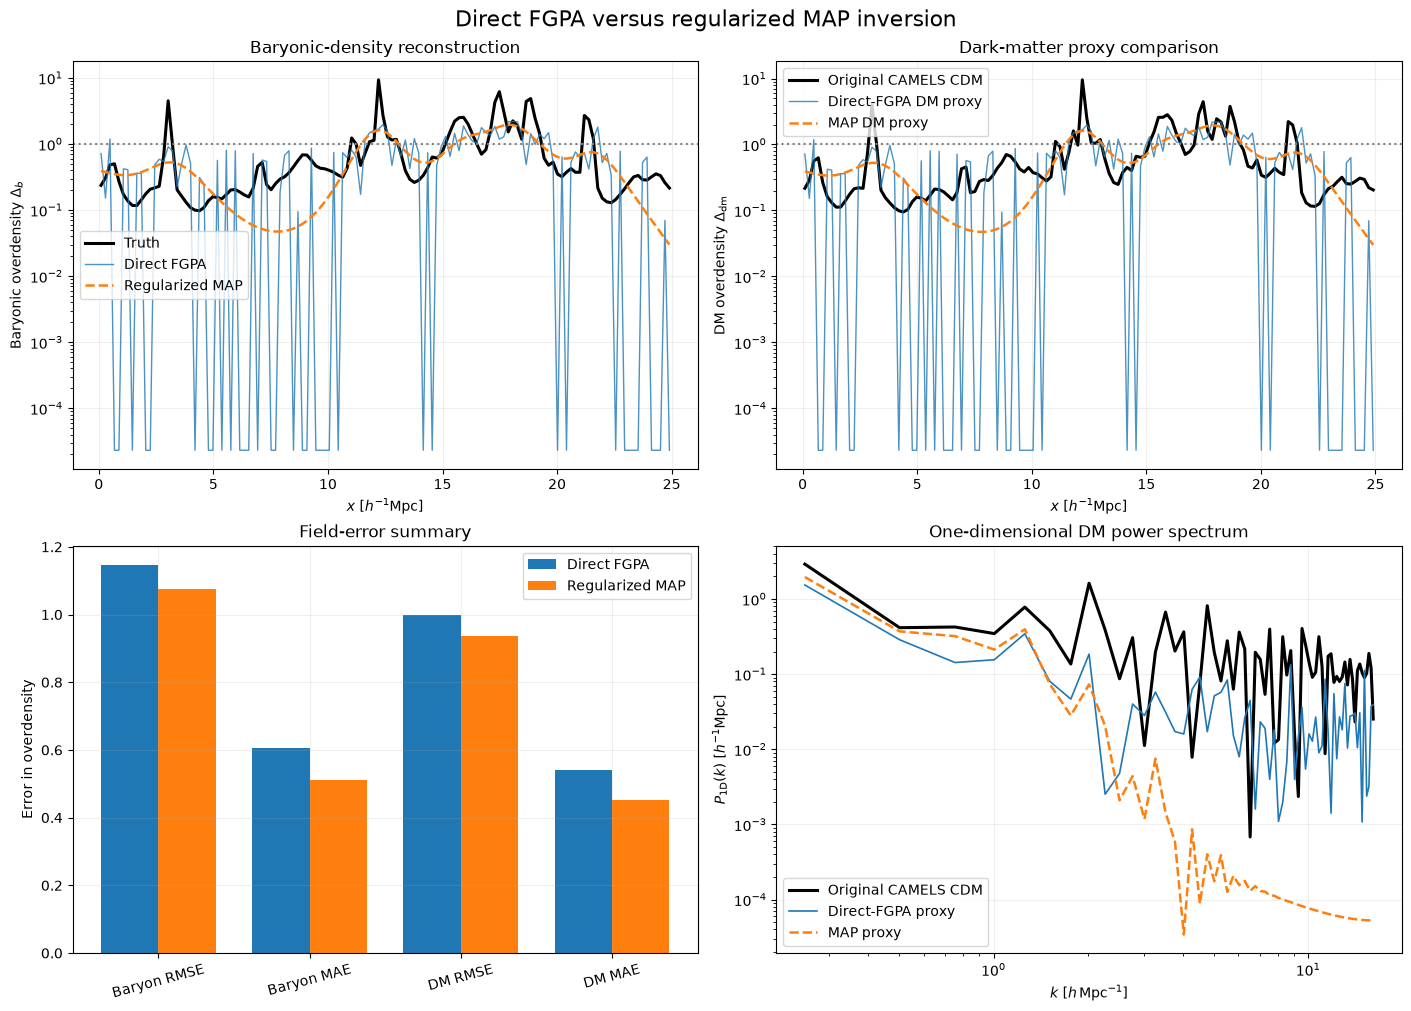

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10), constrained_layout=True)

axes[0, 0].semilogy(x, Delta_b_true, color="black", lw=2.2, label="Truth")
axes[0, 0].semilogy(x, Delta_b_direct, color="tab:blue", lw=1.0, alpha=0.8, label="Direct FGPA")
axes[0, 0].semilogy(x, Delta_b_map, "--", color="tab:orange", lw=1.8, label="Regularized MAP")
axes[0, 0].axhline(1.0, color="0.5", ls=":")
axes[0, 0].set_xlabel(r"$x\ [h^{-1}{\rm Mpc}]$")
axes[0, 0].set_ylabel(r"Baryonic overdensity $\Delta_b$")
axes[0, 0].set_title("Baryonic-density reconstruction")
axes[0, 0].legend()

axes[0, 1].semilogy(x, Delta_dm_true, color="black", lw=2.2, label="Original CAMELS CDM")
axes[0, 1].semilogy(x, Delta_dm_direct, color="tab:blue", lw=1.0, alpha=0.8, label="Direct-FGPA DM proxy")
axes[0, 1].semilogy(x, Delta_dm_map, "--", color="tab:orange", lw=1.8, label="MAP DM proxy")
axes[0, 1].axhline(1.0, color="0.5", ls=":")
axes[0, 1].set_xlabel(r"$x\ [h^{-1}{\rm Mpc}]$")
axes[0, 1].set_ylabel(r"DM overdensity $\Delta_{\rm dm}$")
axes[0, 1].set_title("Dark-matter proxy comparison")
axes[0, 1].legend()

metric_labels = ["Baryon RMSE", "Baryon MAE", "DM RMSE", "DM MAE"]
direct_values = [
    metrics["Baryon: direct FGPA"]["RMSE"],
    metrics["Baryon: direct FGPA"]["MAE"],
    metrics["DM proxy: direct FGPA"]["RMSE"],
    metrics["DM proxy: direct FGPA"]["MAE"],
]
map_values = [
    metrics["Baryon: MAP"]["RMSE"],
    metrics["Baryon: MAP"]["MAE"],
    metrics["DM proxy: MAP"]["RMSE"],
    metrics["DM proxy: MAP"]["MAE"],
]
positions = np.arange(len(metric_labels))
width = 0.38
axes[1, 0].bar(positions - width / 2, direct_values, width, color="tab:blue", label="Direct FGPA")
axes[1, 0].bar(positions + width / 2, map_values, width, color="tab:orange", label="Regularized MAP")
axes[1, 0].set_xticks(positions, metric_labels, rotation=15)
axes[1, 0].set_ylabel("Error in overdensity")
axes[1, 0].set_title("Field-error summary")
axes[1, 0].legend()

axes[1, 1].loglog(k_dm, power_dm_true, color="black", lw=2.2, label="Original CAMELS CDM")
axes[1, 1].loglog(k_dm, power_dm_direct, color="tab:blue", lw=1.2, label="Direct-FGPA proxy")
axes[1, 1].loglog(k_dm, power_dm_map, "--", color="tab:orange", lw=1.8, label="MAP proxy")
axes[1, 1].set_xlabel(r"$k\ [h\,{\rm Mpc}^{-1}]$")
axes[1, 1].set_ylabel(r"$P_{1\rm D}(k)\ [h^{-1}{\rm Mpc}]$")
axes[1, 1].set_title("One-dimensional DM power spectrum")
axes[1, 1].legend()

for ax in axes.flat:
    ax.grid(alpha=0.2)

fig.suptitle("Direct FGPA versus regularized MAP inversion", fontsize=16)
fig.savefig(output_directory / "MAP_vs_direct_FGPA.png", dpi=150, bbox_inches="tight")
plt.show()

## 9. Interpretation

- Direct FGPA is exact for the ideal local forward model, but it does not undo an instrumental convolution and is unstable when noise pushes flux outside its physical interval.
- MAP inversion compares a complete forward prediction with the data. The curvature prior stabilizes modes that the LSF and noise do not constrain.
- Regularization introduces bias: narrow peaks are suppressed when the data cannot support them. A smooth reconstruction is not automatically a more accurate reconstruction.
- The residual check tests whether the selected density can reproduce the measured flux at the stated noise level.
- Mock generation uses actual CAMELS temperatures, but both inversions use only flux plus the stated $T_0$–$\gamma$ assumption. This intentional mismatch represents the information available for an observation.
- The final DM estimate remains a baryon-traces-DM proxy. Differences from CAMELS CDM truth include genuine gas–DM differences as well as inversion error.

### Why the approach generalizes

The reusable pieces are the latent-field parameterization, forward operator, likelihood, and regularizer. For another tracer, replace the density–temperature response with its physical response, provide the appropriate noise covariance, and choose a prior suited to the field.

### Suggested exercises

1. Change S/N or resolving power and repeat the automatic $\lambda$ selection.
2. Replace the second-difference penalty with a first-difference penalty and compare peak recovery.
3. Vary `inversion_T0_K` and `inversion_gamma` and identify the resulting thermal-model bias.
4. Repeat several noise realizations; a single MAP solution is not a posterior uncertainty estimate.